**GANs: Shape Generation**

In [1]:
import torch

torch.manual_seed(0)  
observations = 2048
train_data = torch.zeros((observations, 2))   

train_data[:,0]=50*torch.rand(observations)    

train_data[:,1]=1.08**train_data[:,0]    

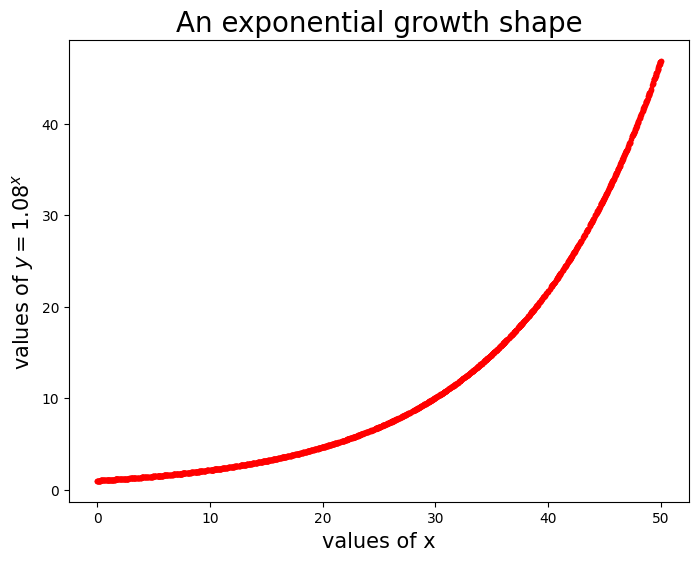

In [2]:
import matplotlib.pyplot as plt

fig=plt.figure(dpi=100,figsize=(8,6))
plt.plot(train_data[:,0],train_data[:,1],".",c="r")    #A
plt.xlabel("values of x",fontsize=15)
plt.ylabel("values of $y=1.08^x$",fontsize=15)    #B
plt.title("An exponential growth shape",fontsize=20)    #C
plt.show()

In [3]:
from torch.utils.data import DataLoader

batch_size=128
train_loader=DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True)

In [4]:
batch0=next(iter(train_loader))

判别器网络

- 输入：数据点
- 输出：true/false


In [5]:
import torch.nn as nn

device="cuda" if torch.cuda.is_available() else "cpu"

D=nn.Sequential(
    nn.Linear(2,256),
    nn.ReLU(),
    nn.Dropout(0.3),    # 防止模型过拟合
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64,1),    
    nn.Sigmoid()).to(device)

生成器网络

将潜空间的一个随机噪声向量输入，生成一对虚假数据

In [6]:
G=nn.Sequential(
    nn.Linear(2,16),    #A
    nn.ReLU(),
    nn.Linear(16,32),
    nn.ReLU(),
    nn.Linear(32,2)).to(device)    #B

In [7]:
loss_fn=nn.BCELoss() # 二叉交叉熵损失
lr=0.0005
optimD=torch.optim.Adam(D.parameters(),lr=lr)
optimG=torch.optim.Adam(G.parameters(),lr=lr)

In [8]:
mse=nn.MSELoss()

def performance(fake_samples):
    real=1.08**fake_samples[:,0]
    mseloss=mse(fake_samples[:,1],real)  
    return mseloss

In [9]:
class EarlyStop:
    def __init__(self, patience=1000):    #A
        self.patience = patience
        self.steps = 0
        self.min_gdif = float('inf')
    def stop(self, gdif):    #B
        if gdif < self.min_gdif:    #C
            self.min_gdif = gdif
            self.steps = 0
        elif gdif >= self.min_gdif:
            self.steps += 1
        if self.steps >= self.patience:    # 如果模型在1000个轮次内均未发生改进，则停止训练
            return True
        else:
            return False

stopper=EarlyStop()

Train the GANs

In [10]:
real_labels=torch.ones((batch_size,1))
real_labels=real_labels.to(device)

fake_labels=torch.zeros((batch_size,1))
fake_labels=fake_labels.to(device)

In [11]:
def train_D_on_real(real_samples):
    real_samples=real_samples.to(device)
    optimD.zero_grad()
    out_D=D(real_samples)    #A
    loss_D=loss_fn(out_D,real_labels)    #B
    loss_D.backward()
    optimD.step()    #C
    return loss_D

In [12]:
def train_D_on_fake():        
    noise=torch.randn((batch_size,2))
    noise=noise.to(device)
    fake_samples=G(noise)     #A       
    optimD.zero_grad()
    out_D=D(fake_samples)    #B
    loss_D=loss_fn(out_D,fake_labels)    #C
    loss_D.backward()
    optimD.step()    #D
    return loss_D

In [ ]:
def train_G(): 
    noise=torch.randn((batch_size,2))
    noise=noise.to(device)
    optimG.zero_grad()
    fake_samples = G(noise)  
    out_G = D(fake_samples)    
    loss_G = loss_fn(out_G,real_labels)    
    loss_G.backward()
    optimG.step() 
    return loss_G, fake_samples 

In [ ]:
import os
os.makedirs("results", exist_ok=True)   

def test_epoch(epoch,gloss,dloss,n,fake_samples):
    if epoch==0 or (epoch+1)%100==0:
        g = gloss.item()/n
        d = dloss.item()/n
        print(f"at epoch {epoch+1}, G loss: {g}, D loss {d}")  
        fake=fake_samples.detach().cpu().numpy()
        plt.figure(dpi=200)
        plt.plot(fake[:,0],fake[:,1],"*",c="g",
            label="generated samples")  
        plt.plot(train_data[:,0],train_data[:,1],".",c="r",
            alpha=0.1,label="real samples")   
        plt.title(f"epoch {epoch+1}")
        plt.xlim(0,50)
        plt.ylim(0,50)
        plt.legend()
        # plt.savefig(f"files/p{epoch+1}.png")
        plt.show()

at epoch 1, G loss: 0.745620854695638, D loss 1.4737932840983072


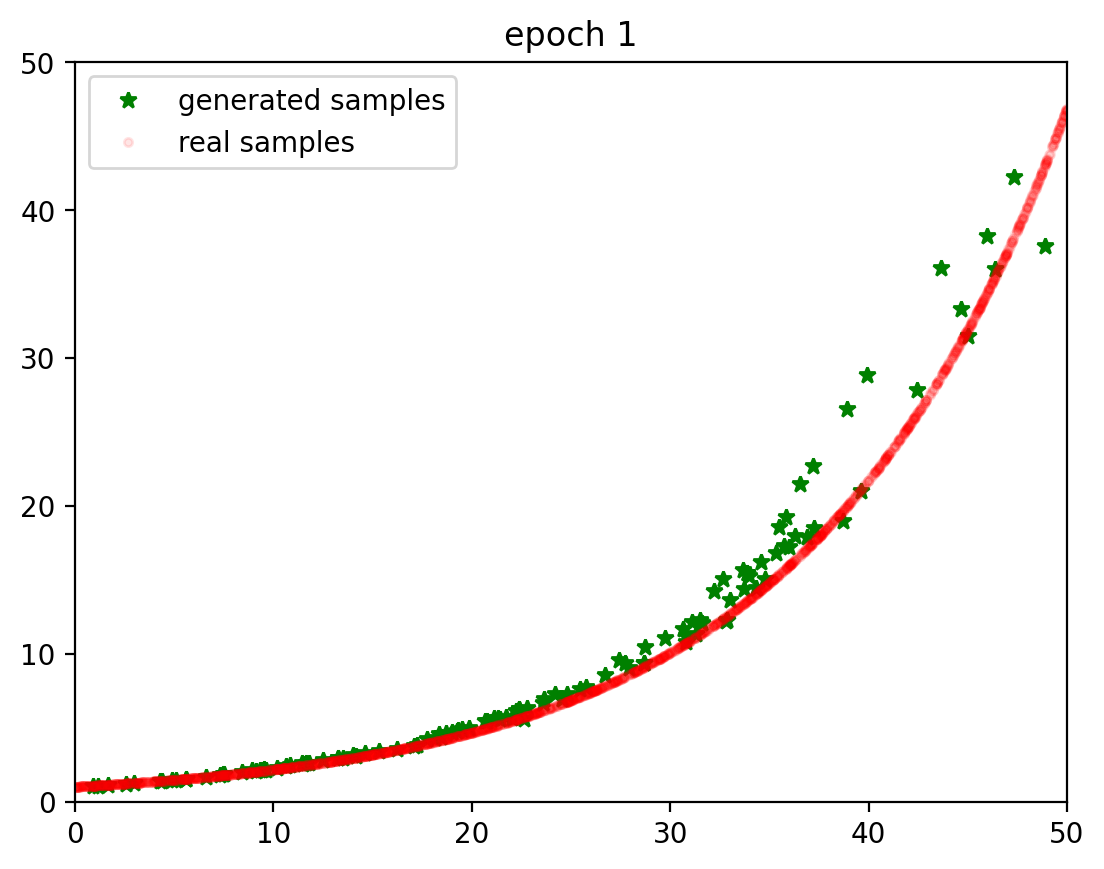

at epoch 100, G loss: 0.7614338556925456, D loss 1.4636910756429036


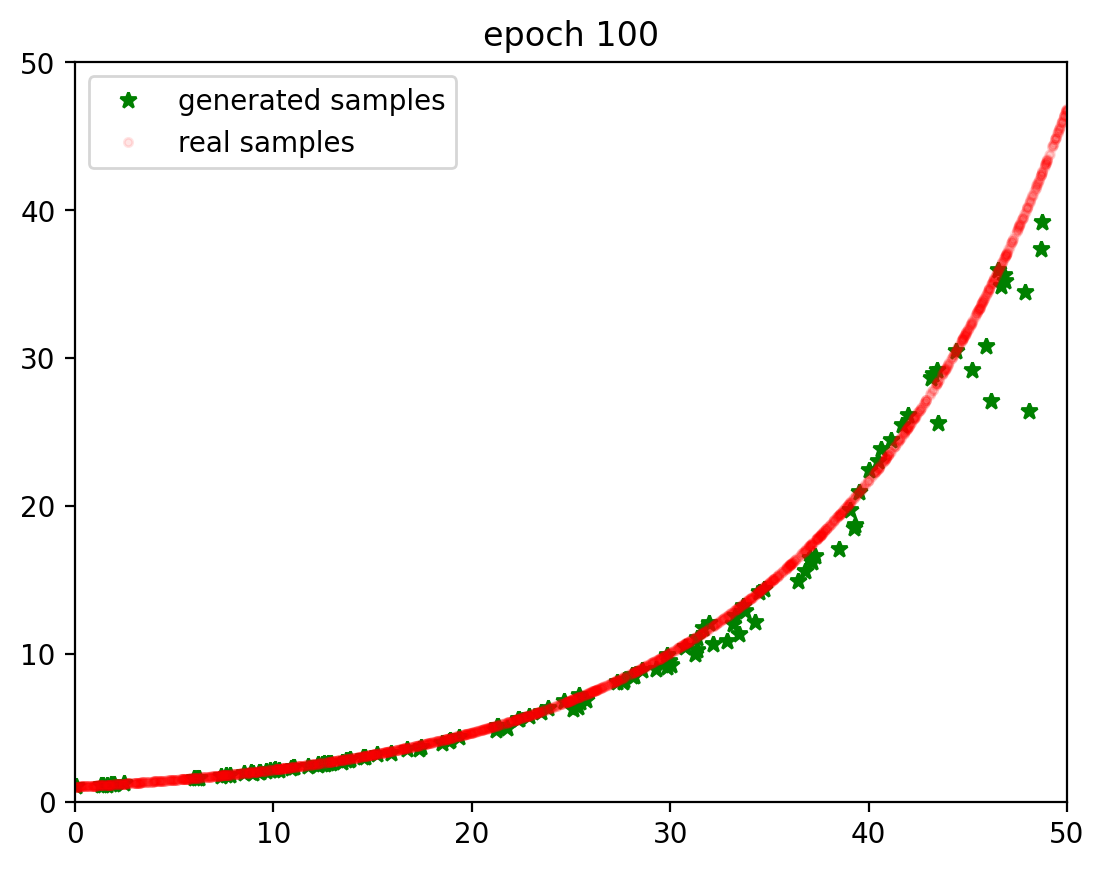

at epoch 200, G loss: 0.7685136795043945, D loss 1.4596762339274088


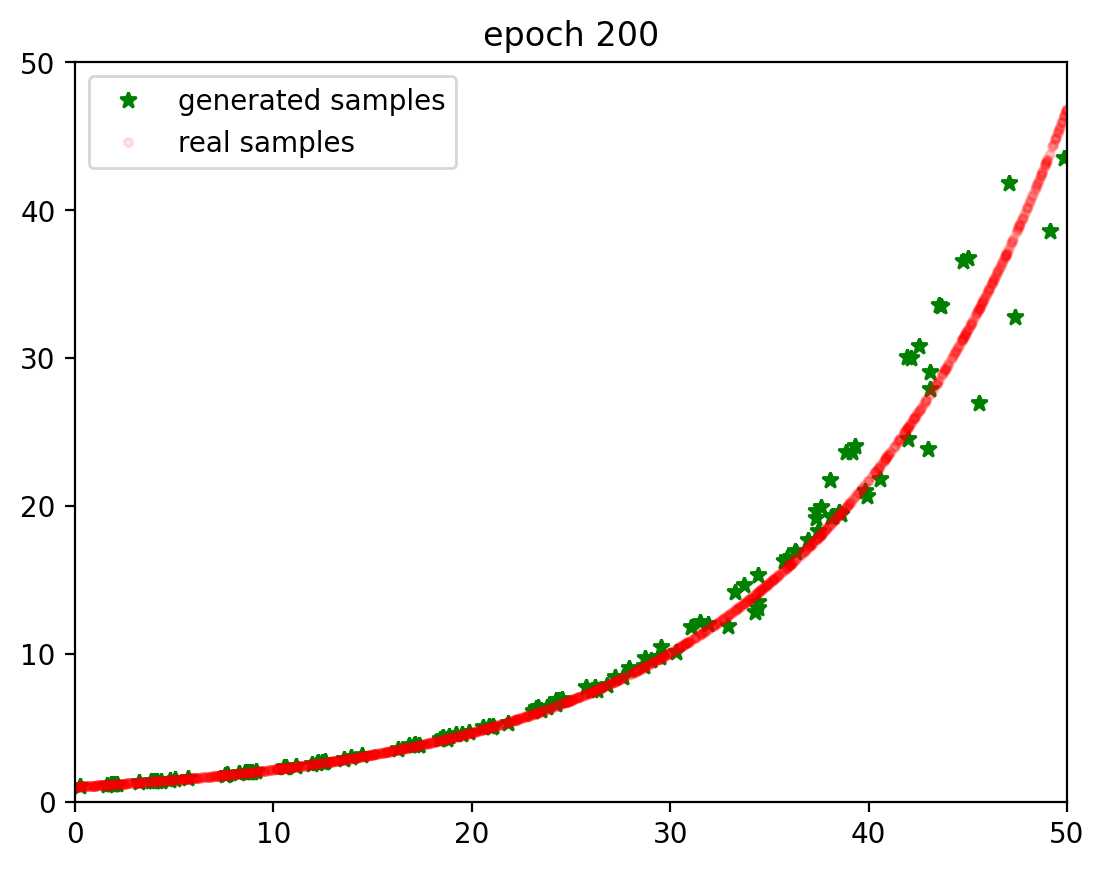

In [ ]:
for epoch in range(10000):    
    gloss=0
    dloss=0
    for n, real_samples in enumerate(train_loader):    
        loss_D=train_D_on_real(real_samples)
        dloss+=loss_D
        loss_D=train_D_on_fake()
        dloss+=loss_D
        loss_G,fake_samples=train_G()
        gloss+=loss_G
    test_epoch(epoch,gloss,dloss,n,fake_samples)    
    gdif=performance(fake_samples).item()
    if stopper.stop(gdif)==True:    #D
        break

Save and Use the Trained Model

In [20]:
import os
os.makedirs("results", exist_ok=True)
scripted = torch.jit.script(G) 
scripted.save('results/exponential.pt') 

In [22]:
new_G=torch.jit.load('results/exponential.pt',
                     map_location=device)

In [23]:
noise=torch.randn((batch_size,2)).to(device)
new_data=new_G(noise) 

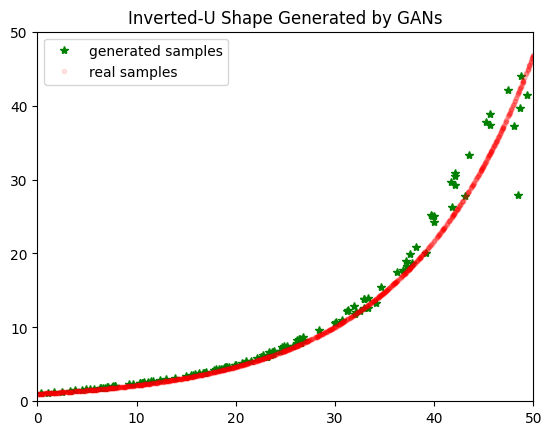

In [ ]:
fig=plt.figure(dpi=100)
plt.plot(new_data.detach().cpu().numpy()[:,0],
  new_data.detach().cpu().numpy()[:,1],"*",c="g",
        label="generated samples")   
plt.plot(train_data[:,0],train_data[:,1],".",c="r",
         alpha=0.1,label="real samples")    
plt.title("Inverted-U Shape Generated by GANs")
plt.xlim(0,50)
plt.ylim(0,50)
plt.legend()
plt.show()